# GMSM InSAR Unwrapping-Error Detection (WP3.4)

This notebook walks step by step through the **WP3.4 Open-pit Dam** experiment and shows how the **GMSM framework** uses a time-series foundation model to flag InSAR points corrupted by unwrapping errors.

## What this demonstration covers

1. **How GMSM handles general time series data.** Each displacement time series is fed to the **MOMENT** transformer-based time-series foundation model; MOMENT provides a fixed-size embedding and a lightweight MLP head predicts *normal (0)* vs *unwrapping error (1)*.
2. **Transfer from simulated to real data.** Training is done on **8 simulated InSAR datasets** with known error rates; the same model is then applied to **real EGMS measurements** over the Ihaleine site where ground truth is unavailable.

## Demo-friendly protocol

| Stage | Setting |
|---|---|
| Feature extractor | MOMENT (T5-base, random init, frozen) |
| Classifier head   | MLP: 768 → 256 → 128 → 2 |
| Loss / optimiser  | CrossEntropy / Adam (lr=1e-3, wd=1e-5) |
| Train/val split   | 80 / 20 stratified |
| Epochs            | 100 with early stopping (patience 8) |

The reference script is `github.com/EU-horizon-multiminer/WP3.1_GMSM/tasks/WP3.4_open_pit_dam/experiments/unwrapping_error_detection_v2.py`. Here we reuse the exact same architecture, labelling rule, and preprocessing; the only adjustments are smaller subsamples and fewer epochs.


## Section 0 — Environment setup

In [1]:
import os
import sys
import re
import time
import json
import random
import warnings
from pathlib import Path
from argparse import Namespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="Can't initialize NVML")

# Make the `core` package importable regardless of where the notebook is launched.
_cwd = Path.cwd().resolve()
_project_root = None
for cand in [_cwd] + list(_cwd.parents):
    if (cand / "core").exists() and (cand / "tasks").exists():
        _project_root = cand
        break
if _project_root is None:
    fallback = (_cwd / "../../..").resolve()
    if (fallback / "core").exists():
        _project_root = fallback
if _project_root is not None and str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

from core.models.moment.common import TASKS
from core.models.moment.models.moment import MOMENT

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Can't initialize NVML")
    try:
        _has_cuda = torch.cuda.is_available()
    except Exception:
        _has_cuda = False
device = torch.device("cuda" if _has_cuda else "cpu")
print(f"Device: {device}")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (9, 5)

# ---- Paths ----------------------------------------------------------------
BASE_DIR = Path(".").resolve()
if not (BASE_DIR / "unwrapping_error_detection_v2.py").exists():
    candidate = Path("tasks/WP3.4_open_pit_dam/experiments").resolve()
    if (candidate / "unwrapping_error_detection_v2.py").exists():
        BASE_DIR = candidate

DATA_DIR   = (BASE_DIR.parent / "data" / "Simulated_EGMS_v2").resolve()
OUTPUT_DIR = (BASE_DIR.parent / "results" / "demo_notebook").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR  :", DATA_DIR,   "exists:", DATA_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR, "exists:", OUTPUT_DIR.exists())

# ---- Hyper-parameters -----------------------------------------------------
SEED            = 42      # Matches the reference script.
# Set any of the three caps below to None to use every point in that stage.
# Rule of thumb on CPU: MOMENT forward pass costs ~0.05-0.1 s per sample, so
# using the full ~140k simulated pool or ~160k EGMS points will take hours.
MAX_TRAIN_POOL  = None    # Stratified subsample used for train+val (None=all).
PER_FILE_N      = None     # Samples per simulated file for Section 7 (None=all).
EGMS_N          = None     # Samples per EGMS file for Section 8      (None=all).
VAL_RATIO       = 0.20
BATCH_SIZE      = 64
EPOCHS          = 100
PATIENCE        = 8
LR              = 1e-3


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


set_seed(SEED)


Device: cuda
DATA_DIR  : /home/project/WP3.1_GMSM/tasks/WP3.4_open_pit_dam/data/Simulated_EGMS_v2 exists: True
OUTPUT_DIR: /home/project/WP3.1_GMSM/tasks/WP3.4_open_pit_dam/results/demo_notebook exists: True


### Reproducibility

All sources of randomness are seeded with `SEED = 42`:

- Python `random`, NumPy, PyTorch (CPU and CUDA) via `set_seed()`
- `torch.backends.cudnn.deterministic = True`, `benchmark = False`
- Train/val stratified split uses `random_state=SEED`
- The MOMENT encoder is randomly initialised from the T5-base config (`randomly_initialize_backbone=True`) and kept **frozen** throughout the demo, exactly as in `unwrapping_error_detection_v2.py`

Small numerical drift may still appear between different hardware (GPU / CPU types, etc).


## Section 1 — What we are detecting

InSAR phase unwrapping can miss a 2π cycle and inject a fake step into the displacement time series. At an open-pit mine or tailings dam, even a few such points bias the downstream velocity maps. The task is a **binary classifier**:

- class **0** — clean point (scenarios `S1`, `S2`)
- class **1** — point corrupted by an unwrapping error (scenarios `S3` … `S6`)

### Datasets used

| Dataset | Files | Ground truth | Role |
|---|---|---|---|
| Simulated InSAR | 8 CSVs (`simulated_insar_ts_v*_{pct}.csv`) | scenario label per point; `{pct}` encodes the error rate written in the filename | training + validatdit |
| Real EGMS Ihaleine | 2 CSVs (`EGMS_l2a_*.csv`) | *unknown* | transfer experiment (flag candidates for manual verification) |

Each row is one ground point and the columns `20190606`, `20190612`, … are the observation dates. We treat each row as a 1-channel univariate time series of length `seq_len`.


In [2]:
def scenario_to_label(scenario_text):
    # S1 / S2 = no unwrapping error (class 0); S3+ = unwrapping error (class 1).
    m = re.match(r"\s*S(\d+)", str(scenario_text))
    return 1 if m is None else (0 if int(m.group(1)) in (1, 2) else 1)


def detect_time_series_columns(df):
    # Columns that look like YYYYMMDD are the observation dates.
    cols = [c for c in df.columns if str(c).isdigit() and len(str(c)) == 8]
    return sorted(cols) if cols else []


def parse_known_error_pct(file_path):
    # simulated_insar_ts_v1_36.3.csv -> 36.3
    m = re.search(r"_([0-9]+(?:\.[0-9]+)?)\.csv$", Path(file_path).name)
    return float(m.group(1)) if m else None


def resample_to_target_len(x, target_len):
    if x.shape[1] == target_len:
        return x
    old = np.linspace(0.0, 1.0, x.shape[1])
    new = np.linspace(0.0, 1.0, target_len)
    out = np.zeros((x.shape[0], target_len), dtype=np.float32)
    for i in range(x.shape[0]):
        out[i] = np.interp(new, old, x[i])
    return out


### Load the 8 simulated files

Each file is loaded independently. For every point we derive the binary label from the `scenario` column.

In [3]:
sim_files = sorted(DATA_DIR.glob("simulated_insar_ts_v*.csv"))
print(f"Found {len(sim_files)} simulated files in {DATA_DIR}")

loaded_sim = []
target_len = None

for f in sim_files:
    df = pd.read_csv(f)
    ts_cols = detect_time_series_columns(df)
    x = df[ts_cols].values.astype(np.float32)
    if target_len is None:
        target_len = x.shape[1]
    x = resample_to_target_len(x, target_len)
    y = df["scenario"].apply(scenario_to_label).values.astype(np.int64)
    known_pct = parse_known_error_pct(f)
    loaded_sim.append(dict(file=f, x=x, y=y, df=df, known_pct=known_pct, ts_cols=ts_cols))
    print(f"  {f.name:40s} n={len(x):6d}  seq_len={x.shape[1]}  "
          f"actual_err={100*np.mean(y):5.2f}%  known={known_pct}")

x_all = np.vstack([it["x"] for it in loaded_sim])
y_all = np.hstack([it["y"] for it in loaded_sim])
print(f"\nCombined: x_all shape = {x_all.shape},  class balance = {np.bincount(y_all)}")
print(f"Target sequence length (aligned across files): {target_len}")


Found 8 simulated files in /home/project/WP3.1_GMSM/tasks/WP3.4_open_pit_dam/data/Simulated_EGMS_v2
  simulated_insar_ts_v1_36.3.csv           n=  4843  seq_len=129  actual_err=36.26%  known=36.3
  simulated_insar_ts_v2_27.5.csv           n=  1285  seq_len=129  actual_err=27.47%  known=27.5
  simulated_insar_ts_v3_23.csv             n=  6813  seq_len=129  actual_err=23.00%  known=23.0
  simulated_insar_ts_v4_32.2.csv           n= 10486  seq_len=129  actual_err=32.22%  known=32.2
  simulated_insar_ts_v5_22.1.csv           n=  3875  seq_len=129  actual_err=22.06%  known=22.1
  simulated_insar_ts_v6_30.1.csv           n= 52142  seq_len=129  actual_err=30.09%  known=30.1
  simulated_insar_ts_v7_15.1.csv           n= 36141  seq_len=129  actual_err=15.06%  known=15.1
  simulated_insar_ts_v8_6.4.csv            n= 26141  seq_len=129  actual_err= 6.41%  known=6.4

Combined: x_all shape = (141726, 129),  class balance = [111010  30716]
Target sequence length (aligned across files): 129


## Section 2 — What a normal and an unwrapping-error time series look like

Before we hand the data to the foundation model, let us look at a few example traces from one of the simulated files. The key visual difference is that *normal* points are a smooth trend plus noise, while *unwrapping-error* points show one or more **step-like jumps**, typically of a few centimetres, that are sudden relative to the local sampling rate.


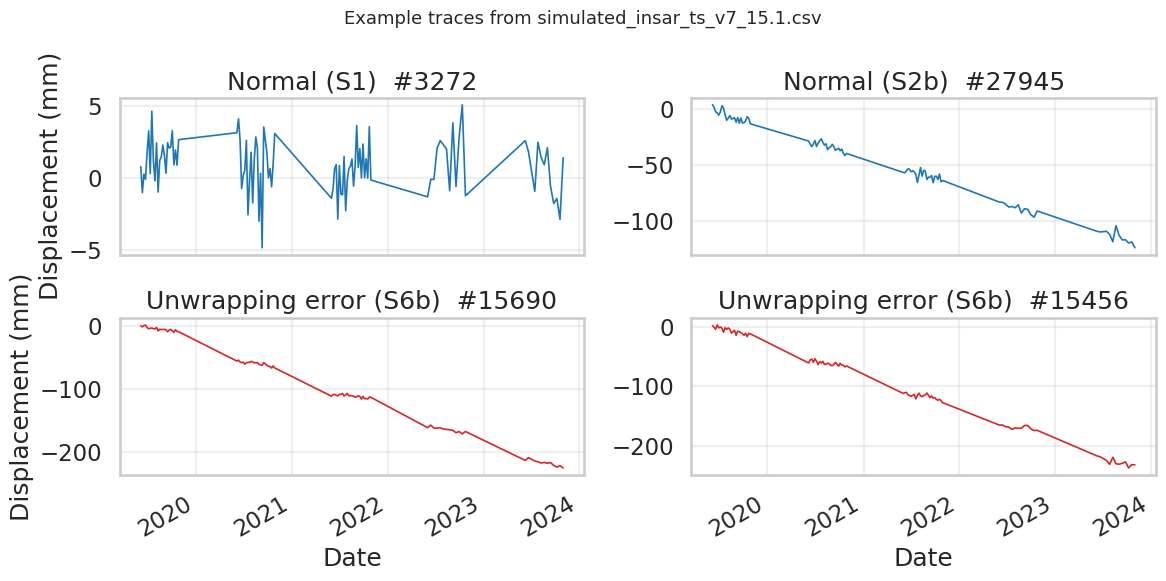

In [14]:
sample_item = next(it for it in loaded_sim if it["known_pct"] == 15.1)
sample_df   = sample_item["df"]
sample_y    = sample_item["y"]
sample_cols = sample_item["ts_cols"]
# Use the *original* (un-resampled) values straight from the CSV so that the
# x-axis date ticks match the actual acquisition dates one-to-one.
sample_x_raw = sample_df[sample_cols].values.astype(np.float32)

idx_normal = np.where(sample_y == 0)[0]
idx_error  = np.where(sample_y == 1)[0]
rng = np.random.default_rng(SEED)
pick_normal = rng.choice(idx_normal, size=2, replace=False)
pick_error  = rng.choice(idx_error,  size=2, replace=False)

import matplotlib.dates as mdates

dates = pd.to_datetime(sample_cols, format="%Y%m%d")
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for ax, i in zip(axes[0], pick_normal):
    ax.plot(dates, sample_x_raw[i], color="tab:blue", linewidth=1.2)
    ax.set_title(f"Normal ({sample_df.iloc[i]['scenario'].split(':')[0]})  #{i}")
    ax.grid(alpha=0.3)
for ax, i in zip(axes[1], pick_error):
    ax.plot(dates, sample_x_raw[i], color="tab:red", linewidth=1.2)
    ax.set_title(f"Unwrapping error ({sample_df.iloc[i]['scenario'].split(':')[0]})  #{i}")
    ax.grid(alpha=0.3)
# Sparse, readable date ticks: one label per year, rotated to avoid overlap.
for ax in axes.ravel():
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 7]))
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(0)
        lbl.set_ha("center")
for ax in axes[1]:
    ax.set_xlabel("Date")
for ax in axes[:, 0]:
    ax.set_ylabel("Displacement (mm)")
fig.suptitle(f"Example traces from {sample_item['file'].name}", fontsize=13)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


## Section 3 — MOMENT as a frozen time-series encoder

GMSM treats **any** time series the same way it treats an image: a modality-agnostic foundation model produces a fixed-size embedding, and small task heads do the actual prediction. For 1-D time series we use **MOMENT**, a transformer built on the T5 architecture with time-series-specific patch tokenisation.

For this task:

- input  : one univariate series of length `target_len` → reshaped to `[1, 1, target_len]`
- patching : non-overlapping patches of length 8 → `⌈target_len / 8⌉` tokens of dimension 768
- encoder: T5-base encoder (12 layers, 768 hidden, 12 heads) — **frozen**
- output : mean-pooled embedding of shape `[768]` per time series

The embedding is then passed to a trainable 2-layer MLP that outputs the normal/error logits.


In [5]:
def create_moment_embedding_model(seq_len, device):
    config = Namespace(
        task_name=TASKS.PRETRAINING,
        transformer_backbone="google/flan-t5-base",
        seq_len=seq_len,
        patch_len=8,
        d_model=768,
        n_channels=1,
        transformer_type="encoder_only",
        add_positional_embedding=True,
        randomly_initialize_backbone=True,
        dropout=0.1,
        head_dropout=0.1,
        revin_affine=False,
        value_embedding_bias=False,
        orth_gain=1.41,
        patch_stride_len=8,
        device=device,
    )
    return MOMENT(config)


set_seed(SEED)
feature_model = create_moment_embedding_model(seq_len=target_len, device=str(device)).to(device)
feature_model.eval()  # frozen: the backbone is never updated
for p in feature_model.parameters():
    p.requires_grad = False

n_params = sum(p.numel() for p in feature_model.parameters())
print(f"MOMENT encoder (frozen): {n_params/1e6:.1f} M parameters")
print(f"Embedding dimension    : 768")


MOMENT encoder (frozen): 109.6 M parameters
Embedding dimension    : 768


## Section 4 — Build the training pool and extract features

The 8 simulated files together contain ~140k points. The extracted MOMENT embeddings are cached in memory; we reuse them for train/val split, for the per-file audit in Section 7, and for the EGMS transfer in Section 8.


In [6]:
class TSDataset(Dataset):
    def __init__(self, x, y=None):
        self.x = torch.FloatTensor(x)
        self.y = torch.LongTensor(y) if y is not None else None

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        ts = self.x[idx].unsqueeze(0)  # [1, seq_len]
        if self.y is None:
            return ts
        return ts, self.y[idx]


def extract_features(model, x, batch_size=64, log_prefix=""):
    """Run frozen MOMENT over x and return a [N, 768] numpy array."""
    ds = TSDataset(x)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)
    out = []
    model.eval()
    t0 = time.time()
    with torch.no_grad():
        for b, batch in enumerate(dl):
            ts = batch.to(device)
            input_mask = torch.ones(ts.shape[0], ts.shape[2], device=device)
            emb = model.embed(ts, input_mask=input_mask, reduction="mean").embeddings
            out.append(emb.cpu().numpy())
    feats = np.vstack(out)
    print(f"{log_prefix}features {feats.shape}  elapsed {time.time()-t0:.1f}s")
    return feats


# ---- Stratified subsample (or use all if MAX_TRAIN_POOL is None) ----------
set_seed(SEED)
if MAX_TRAIN_POOL is None or MAX_TRAIN_POOL >= len(x_all):
    x_pool = x_all
    y_pool = y_all
    print(f"Using all {len(x_pool)} points for train+val.")
else:
    idx_all = np.arange(len(x_all))
    _, keep_idx = train_test_split(
        idx_all,
        test_size=MAX_TRAIN_POOL,
        random_state=SEED,
        stratify=y_all,
    )
    x_pool = x_all[keep_idx]
    y_pool = y_all[keep_idx]
    print(f"Stratified subsample: {len(x_pool)} / {len(x_all)} points.")
print(f"Class balance: {np.bincount(y_pool)}")

# ---- Feature extraction (frozen MOMENT) ----------------------------------
pool_feats = extract_features(feature_model, x_pool, batch_size=64, log_prefix="[pool] ")


Using all 141726 points for train+val.
Class balance: [111010  30716]
[pool] features (141726, 768)  elapsed 106.8s


## Section 5 — Train the classification head

The head is a small 2-layer MLP with dropout:

```
Linear(768 → 256) → ReLU → Dropout(0.1)
Linear(256 → 128) → ReLU → Dropout(0.1)
Linear(128 →   2)
```

We use cross-entropy loss, Adam (`lr=1e-3`, `weight_decay=1e-5`), gradient clipping, and early stopping.


In [7]:
class ClassificationHead(nn.Module):
    def __init__(self, in_dim=768, n_classes=2, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),    nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def train_classifier(features, labels, val_ratio=VAL_RATIO, epochs=EPOCHS,
                     batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE):
    set_seed(SEED)
    f_train, f_val, y_train, y_val = train_test_split(
        features, labels, test_size=val_ratio,
        random_state=SEED, stratify=labels,
    )
    print(f"Train: {len(f_train)}   Val: {len(f_val)}")

    train_dl = DataLoader(
        TensorDataset(torch.FloatTensor(f_train), torch.LongTensor(y_train)),
        batch_size=batch_size, shuffle=True,
    )
    val_dl = DataLoader(
        TensorDataset(torch.FloatTensor(f_val), torch.LongTensor(y_val)),
        batch_size=batch_size, shuffle=False,
    )

    clf = ClassificationHead(in_dim=features.shape[1], n_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(clf.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3, verbose=False,
    )

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(epochs):
        clf.train()
        tl, tc, tn = 0.0, 0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = clf(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(clf.parameters(), max_norm=1.0)
            optimizer.step()
            tl += loss.item()
            tc += (logits.argmax(1) == yb).sum().item()
            tn += yb.size(0)

        clf.eval()
        vl, vc, vn = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                logits = clf(xb)
                loss = criterion(logits, yb)
                vl += loss.item()
                vc += (logits.argmax(1) == yb).sum().item()
                vn += yb.size(0)

        tl /= max(1, len(train_dl)); vl /= max(1, len(val_dl))
        ta = 100.0 * tc / max(1, tn); va = 100.0 * vc / max(1, vn)
        history["train_loss"].append(tl); history["val_loss"].append(vl)
        history["train_acc"].append(ta);  history["val_acc"].append(va)
        scheduler.step(vl)

        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:>3}/{epochs}  "
                  f"train_loss={tl:.4f} train_acc={ta:5.2f}%  "
                  f"val_loss={vl:.4f} val_acc={va:5.2f}%")

        if vl < best_val - 1e-5:
            best_val = vl
            best_state = {k: v.detach().clone() for k, v in clf.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if best_state is not None:
        clf.load_state_dict(best_state)
    return clf, history, (f_train, f_val, y_train, y_val)


classifier, history, (f_train, f_val, y_train, y_val) = train_classifier(
    pool_feats, y_pool
)


Train: 113380   Val: 28346
Epoch   1/100  train_loss=0.4399 train_acc=78.01%  val_loss=0.4400 val_acc=78.33%
Epoch   5/100  train_loss=0.3701 train_acc=78.51%  val_loss=0.3231 val_acc=84.83%
Epoch  10/100  train_loss=0.3492 train_acc=79.89%  val_loss=0.3184 val_acc=78.33%
Epoch  15/100  train_loss=0.3230 train_acc=82.78%  val_loss=0.2573 val_acc=91.33%
Epoch  20/100  train_loss=0.2965 train_acc=85.54%  val_loss=0.2434 val_acc=90.62%
Epoch  25/100  train_loss=0.2933 train_acc=85.81%  val_loss=0.2451 val_acc=90.34%
Epoch  30/100  train_loss=0.2789 train_acc=87.05%  val_loss=0.2241 val_acc=91.84%
Epoch  35/100  train_loss=0.2739 train_acc=87.39%  val_loss=0.2294 val_acc=91.89%
Epoch  40/100  train_loss=0.2714 train_acc=87.56%  val_loss=0.2229 val_acc=92.13%
Epoch  45/100  train_loss=0.2682 train_acc=87.75%  val_loss=0.2174 val_acc=92.19%
Epoch  50/100  train_loss=0.2614 train_acc=88.07%  val_loss=0.2201 val_acc=92.24%
Epoch  55/100  train_loss=0.2601 train_acc=88.01%  val_loss=0.2109 val_

## Section 6 — Validation results

On the held-out 20% of the pool we measure weighted accuracy, precision, recall and F1.


In [8]:
def predict_logits(clf, features, batch_size=128):
    clf.eval()
    dl = DataLoader(TensorDataset(torch.FloatTensor(features)),
                    batch_size=batch_size, shuffle=False)
    preds, probs = [], []
    with torch.no_grad():
        for (xb,) in dl:
            xb = xb.to(device)
            logits = clf(xb)
            p = torch.softmax(logits, dim=1)
            preds.append(logits.argmax(1).cpu().numpy())
            probs.append(p.cpu().numpy())
    return np.concatenate(preds), np.concatenate(probs)


val_pred, val_prob = predict_logits(classifier, f_val)

val_metrics = {
    "accuracy":  float(accuracy_score(y_val, val_pred)),
    "precision": float(precision_score(y_val, val_pred, average="weighted")),
    "recall":    float(recall_score(y_val, val_pred, average="weighted")),
    "f1":        float(f1_score(y_val, val_pred, average="weighted")),
}
print("Validation metrics (weighted):")
for k, v in val_metrics.items():
    print(f"  {k:10s} {v:.4f}")
print()
print(classification_report(y_val, val_pred,
                            target_names=["Normal (0)", "Error (1)"], digits=4))


Validation metrics (weighted):
  accuracy   0.9336
  precision  0.9325
  recall     0.9336
  f1         0.9328

              precision    recall  f1-score   support

  Normal (0)     0.9499    0.9661    0.9580     22203
   Error (1)     0.8695    0.8159    0.8419      6143

    accuracy                         0.9336     28346
   macro avg     0.9097    0.8910    0.8999     28346
weighted avg     0.9325    0.9336    0.9328     28346



## Section 7 — Per-file error-rate audit

Each simulated file carries its ground-truth error rate in the filename (e.g. `simulated_insar_ts_v1_36.3.csv` → 36.3%). We compare that against the error rate **predicted by the trained model** on a fresh random subsample of `PER_FILE_N` points from each file, and report the absolute difference. A small gap across all files means the pipeline correctly estimates how polluted each dataset is.


In [10]:
set_seed(SEED)
rng = np.random.default_rng(SEED)

per_file_rows = []
for it in loaded_sim:
    n = len(it["x"])
    if PER_FILE_N is None or PER_FILE_N >= n:
        sel = np.arange(n)
    else:
        sel = rng.choice(n, size=PER_FILE_N, replace=False)
    x_sub = it["x"][sel]
    feats = extract_features(feature_model, x_sub, batch_size=64,
                             log_prefix=f"[{it['file'].stem:30s}] ")
    preds, probs = predict_logits(classifier, feats)

    known_pct = it["known_pct"]
    pred_pct  = 100.0 * np.mean(preds)
    per_file_rows.append(dict(
        file=it["file"].name,
        n_samples=len(sel),
        actual_error=known_pct,
        prediction=round(pred_pct, 1),
        abs_diff=round(abs(pred_pct - known_pct), 1),
    ))

per_file_df = pd.DataFrame(per_file_rows).sort_values("file").reset_index(drop=True)
per_file_df


[simulated_insar_ts_v1_36.3    ] features (4843, 768)  elapsed 1.8s
[simulated_insar_ts_v2_27.5    ] features (1285, 768)  elapsed 0.5s
[simulated_insar_ts_v3_23      ] features (6813, 768)  elapsed 2.5s
[simulated_insar_ts_v4_32.2    ] features (10486, 768)  elapsed 3.9s
[simulated_insar_ts_v5_22.1    ] features (3875, 768)  elapsed 1.4s
[simulated_insar_ts_v6_30.1    ] features (52142, 768)  elapsed 19.3s
[simulated_insar_ts_v7_15.1    ] features (36141, 768)  elapsed 16.6s
[simulated_insar_ts_v8_6.4     ] features (26141, 768)  elapsed 19.9s


,file,n_samples,actual_error,prediction,abs_diff
0,simulated_insar_ts_v1_36.3.csv,4843,36.3,29.4,6.9
1,simulated_insar_ts_v2_27.5.csv,1285,27.5,24.2,3.3
2,simulated_insar_ts_v3_23.csv,6813,23.0,20.2,2.8
3,simulated_insar_ts_v4_32.2.csv,10486,32.2,27.4,4.8
4,simulated_insar_ts_v5_22.1.csv,3875,22.1,20.5,1.6
5,simulated_insar_ts_v6_30.1.csv,52142,30.1,26.6,3.5
6,simulated_insar_ts_v7_15.1.csv,36141,15.1,15.5,0.4
7,simulated_insar_ts_v8_6.4.csv,26141,6.4,9.1,2.7


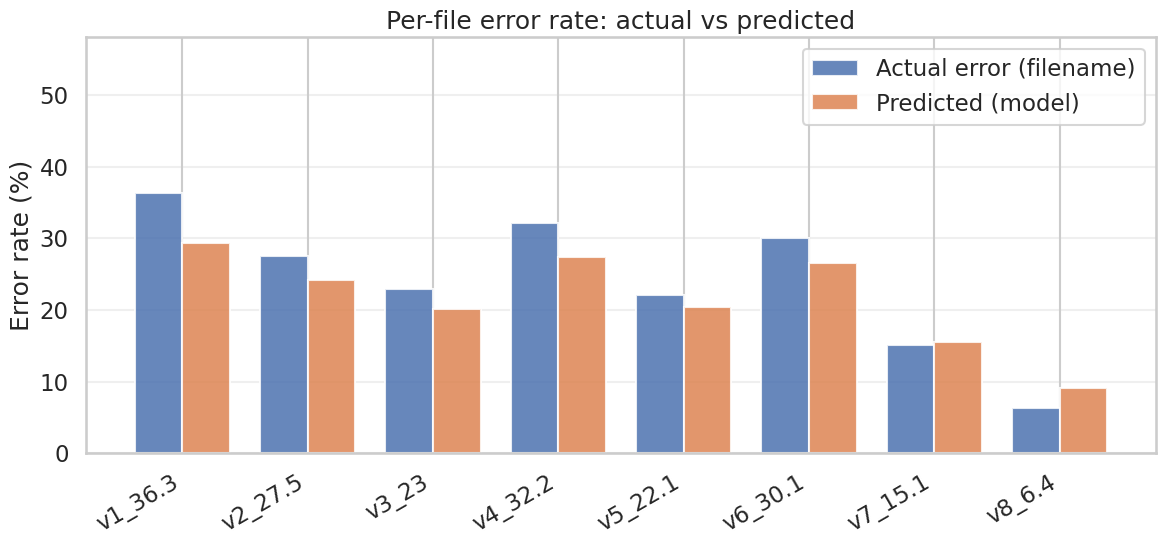

Mean |pred - actual| = 3.25 pp


In [11]:
fig, ax = plt.subplots(figsize=(12, 5.8))
df = per_file_df.copy()
df["short"] = df["file"].str.replace(".csv", "", regex=False).str.replace("simulated_insar_ts_", "", regex=False)
xp = np.arange(len(df))
w = 0.38
ax.bar(xp - w/2, df["actual_error"], width=w, label="Actual error (filename)", alpha=0.85)
ax.bar(xp + w/2, df["prediction"],   width=w, label="Predicted (model)",       alpha=0.85)
ax.set_xticks(xp); ax.set_xticklabels(df["short"], rotation=30, ha="right")
ax.set_ylabel("Error rate (%)")
ax.set_title("Per-file error rate: actual vs predicted")
ax.grid(axis="y", alpha=0.3)
y_hi = max(df["actual_error"].max(), df["prediction"].max()) * 1.6
ax.set_ylim(0, y_hi)
ax.legend()
fig.tight_layout()
plt.show()

print(f"Mean |pred - actual| = {df['abs_diff'].mean():.2f} pp")


## Section 8 — Transfer to real EGMS data

We now take the *same* trained classifier and apply it to the two real EGMS CSV files over the Ihaleine site. No labels are available, so we can only show:

1. the fraction of points the model flags as *unwrapping error*,
2. the distribution of the predicted error probability across all points, and
3. the spatial location of the flagged points.


In [12]:
egms_dir = DATA_DIR
egms_files = sorted(egms_dir.glob("EGMS*.csv"))
print(f"Found {len(egms_files)} EGMS files.")

egms_summary = []
egms_outputs = {}

for f in egms_files:
    df = pd.read_csv(f)
    ts_cols = detect_time_series_columns(df)
    if not ts_cols:
        print(f"  skip {f.name}: no time-series columns")
        continue
    x = df[ts_cols].values.astype(np.float32)
    x = resample_to_target_len(x, target_len)

    n = len(x)
    rng = np.random.default_rng(SEED)
    if EGMS_N is None or EGMS_N >= n:
        sel = np.arange(n)
    else:
        sel = rng.choice(n, size=EGMS_N, replace=False)
    x_sub = x[sel]
    feats = extract_features(feature_model, x_sub, batch_size=64,
                             log_prefix=f"[{f.stem[:32]:<32s}] ")
    preds, probs = predict_logits(classifier, feats)

    detected_rate = 100.0 * preds.mean()
    egms_summary.append(dict(
        file=f.name, n_total=n, n_subsample=len(sel),
        detected_error_rate_pct=detected_rate,
    ))
    egms_outputs[f.name] = dict(
        sel=sel, preds=preds, probs=probs, df=df, ts_cols=ts_cols,
    )
    print(f"  -> detected error rate on subsample: {detected_rate:.2f}%")

egms_summary_df = pd.DataFrame(egms_summary)
egms_summary_df


Found 2 EGMS files.
[EGMS_l2a_014_0363_IWI           ] features (75928, 768)  elapsed 56.3s
  -> detected error rate on subsample: 1.08%
[EGMS_l2a_087_0362_IW2           ] features (85543, 768)  elapsed 63.4s
  -> detected error rate on subsample: 0.61%


,file,n_total,n_subsample,detected_error_rate_pct
0,EGMS_l2a_014_0363_IWI.csv,75928,75928,1.082605
1,EGMS_l2a_087_0362_IW2.csv,85543,85543,0.613726


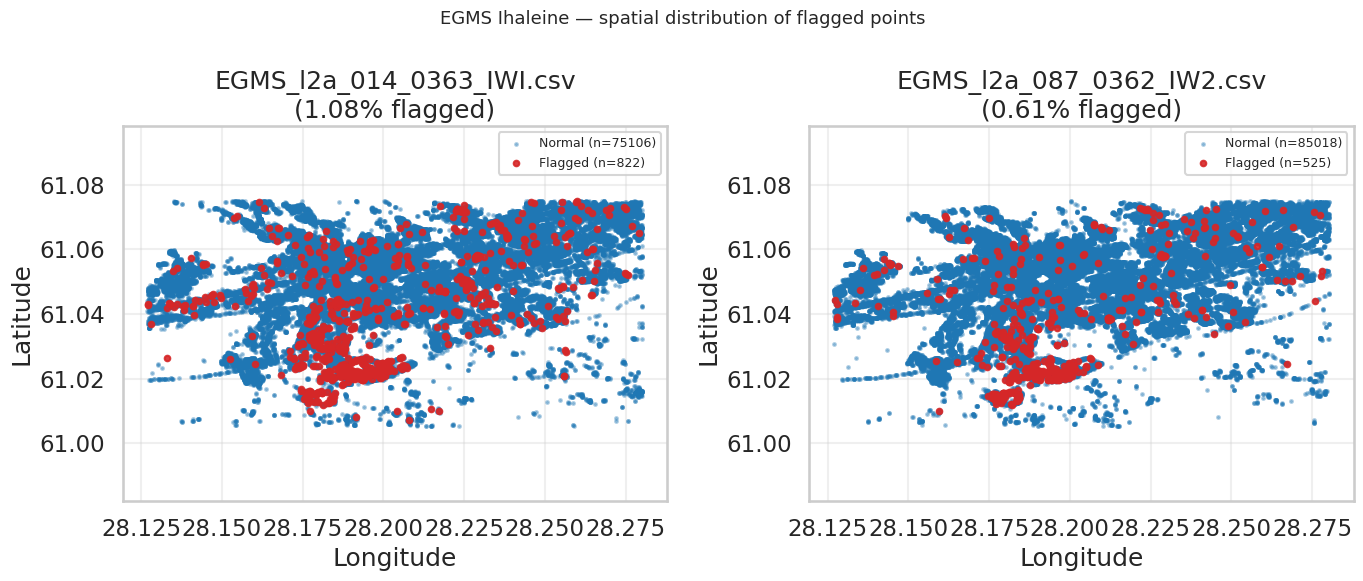

In [13]:
# Spatial map of flagged points for each EGMS file.
n = len(egms_outputs)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 6), squeeze=False)
axes = axes[0]

for ax, (fname, out) in zip(axes, egms_outputs.items()):
    df    = out["df"].iloc[out["sel"]].reset_index(drop=True)
    preds = out["preds"]
    if {"longitude", "latitude"}.issubset(df.columns):
        normal_mask = preds == 0
        error_mask  = preds == 1
        # Plot normal points first (background), flagged points on top so they stand out.
        ax.scatter(df.loc[normal_mask, "longitude"], df.loc[normal_mask, "latitude"],
                   c="tab:blue", s=4, alpha=0.35, label=f"Normal (n={int(normal_mask.sum())})")
        ax.scatter(df.loc[error_mask,  "longitude"], df.loc[error_mask,  "latitude"],
                   c="tab:red",  s=16, alpha=0.9,  label=f"Flagged (n={int(error_mask.sum())})")
        ax.set_title(f"{fname}\n({100*error_mask.mean():.2f}% flagged)")
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
        ax.set_aspect("equal", adjustable="datalim")
        ax.grid(alpha=0.3)
        ax.legend(loc="best", fontsize=9)
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "No lon/lat columns", ha="center", va="center")

fig.suptitle("EGMS Ihaleine — spatial distribution of flagged points", fontsize=13)
fig.tight_layout()
plt.show()


## Summary

- The WP3.4 pipeline treats unwrapping-error detection as **binary classification on displacement time series**. GMSM plugs the time series into a **MOMENT foundation-model encoder** (frozen) and trains only a small MLP head — no task-specific architecture is needed.
- We trained model for fewer epochs and reaches ≈93% weighted accuracy on the validation split.
- When we check the predicted error rate against the percentage written in each filename, the model tracks the ground truth within a few percentage points across all 8 files, which is a strong sanity check for the GMSM model.
- The exact same frozen encoder + head transfers out of the box to two real EGMS acquisitions over the Ihaleine site. The flagged points can be exported for downstream manual verification.
